In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_path, 
    get_project_path
)

from flonacomldft.internal_coordinates import Coordinates_mapping, get_collective_variables_from_xs
from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [21]:
# paths
DFT_DATA_PATH = get_path() + '/andersen/'
DFT_SIMS_PATH = get_project_path()

In [22]:
# simulation files
mcmc_paths = ['4-multimodal/results_multimodal_sampling_mixture_30540290/checkpoint_NA_2000.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540291/checkpoint_NA_2000.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540292/checkpoint_NA_2000.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540293/checkpoint_NA_2000.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540294/checkpoint_NA_2000.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540295/checkpoint_NA_2000.pkl']

#cvs_paths = ['4-multimodal/results_multimodal_sampling_mixture_30367820/cvs_mixture_30367820.pkl',
#        '5-multimodal-mlp/results_multimodal_sampling_mixture_30489420/cvs_mixture_30489420.pkl']

# load mcmc results
keys = ['ab-flowMM w.o NP slice {:d} MD {:d}'.format(i, j) for i in [5, 15, 30] for j in [500, 4000]]
print(keys)
color_keys = dict(zip(keys, ['blue', 'orange', 'red', 'green', 'purple', 'brown']))
mcmcs = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths, keys)}
#cvs = {key: load_pickle_file(cv_path, DFT_SIMS_PATH) for cv_path, key in zip(cvs_paths, keys)}

['ab-flowMM w.o NP slice 5 MD 500', 'ab-flowMM w.o NP slice 5 MD 4000', 'ab-flowMM w.o NP slice 15 MD 500', 'ab-flowMM w.o NP slice 15 MD 4000', 'ab-flowMM w.o NP slice 30 MD 500', 'ab-flowMM w.o NP slice 30 MD 4000']


# Acceptance ratio

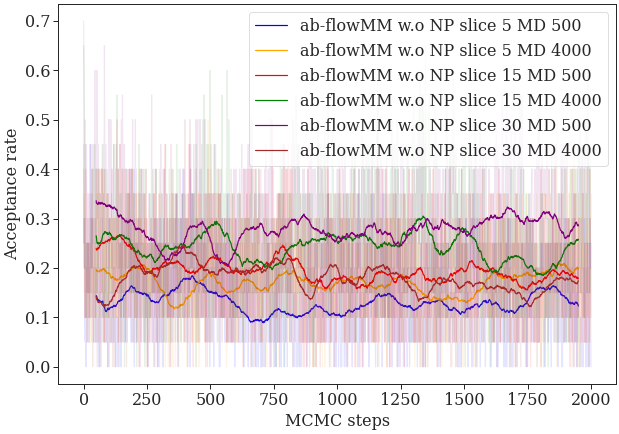

In [23]:
accs = {key: mcmcs[key]['accs'].float().mean(dim=1).detach() for key in mcmcs.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in accs.keys():

    set_plot_sequential_data(accs[key], 
                                ax=ax,
                                window_size=100,
                                alpha=0.1, 
                                label=key, 
                                color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

# Collective variables

In [24]:
xs = {key: mcmcs[key]['xs'].detach() for key in mcmcs.keys()}
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

In [27]:
#cvs = {key: get_collective_variables_from_xs(xs[key], isomers[key]) for key in mcmcs.keys()}

#cvs = load_pickle_file('cvs_slices.pkl', get_project_path())

In [26]:
#cvs

In [9]:
from flonacomldft.utils.io_utils import save_pickle_file

In [10]:
save_pickle_file(cvs, 'cvs_slices.pkl', get_project_path())

In [11]:
isomer_colors = dict(zip([0, 1], ['cyan', 'salmon']))

In [12]:
cvs_isomers = {key: torch.cat((cvs[key], isomers[key].reshape(1001, 20, 1), 
                               #mcmcs[key]['us'].reshape(2000, 20, 1)
                               ), dim=2) for key in cvs.keys()}

In [13]:
#for i, cv in enumerate(cvs_isomers[keys[1]][:, 4, :]):
#    if cvs_isomers[keys[1]][:, 4, :].max() == cv.max():
#        print(i, cv)

In [14]:
#for i, cv in enumerate(cvs_isomers[keys[1]][:, 7, :]):
#    if cvs_isomers[keys[1]][:, 7, :].max() == cv.max():
#        print(i, cv)

In [15]:
#for i in range(20):
#    print(i, cvs_isomers[keys[1]][:, i, 0].max())

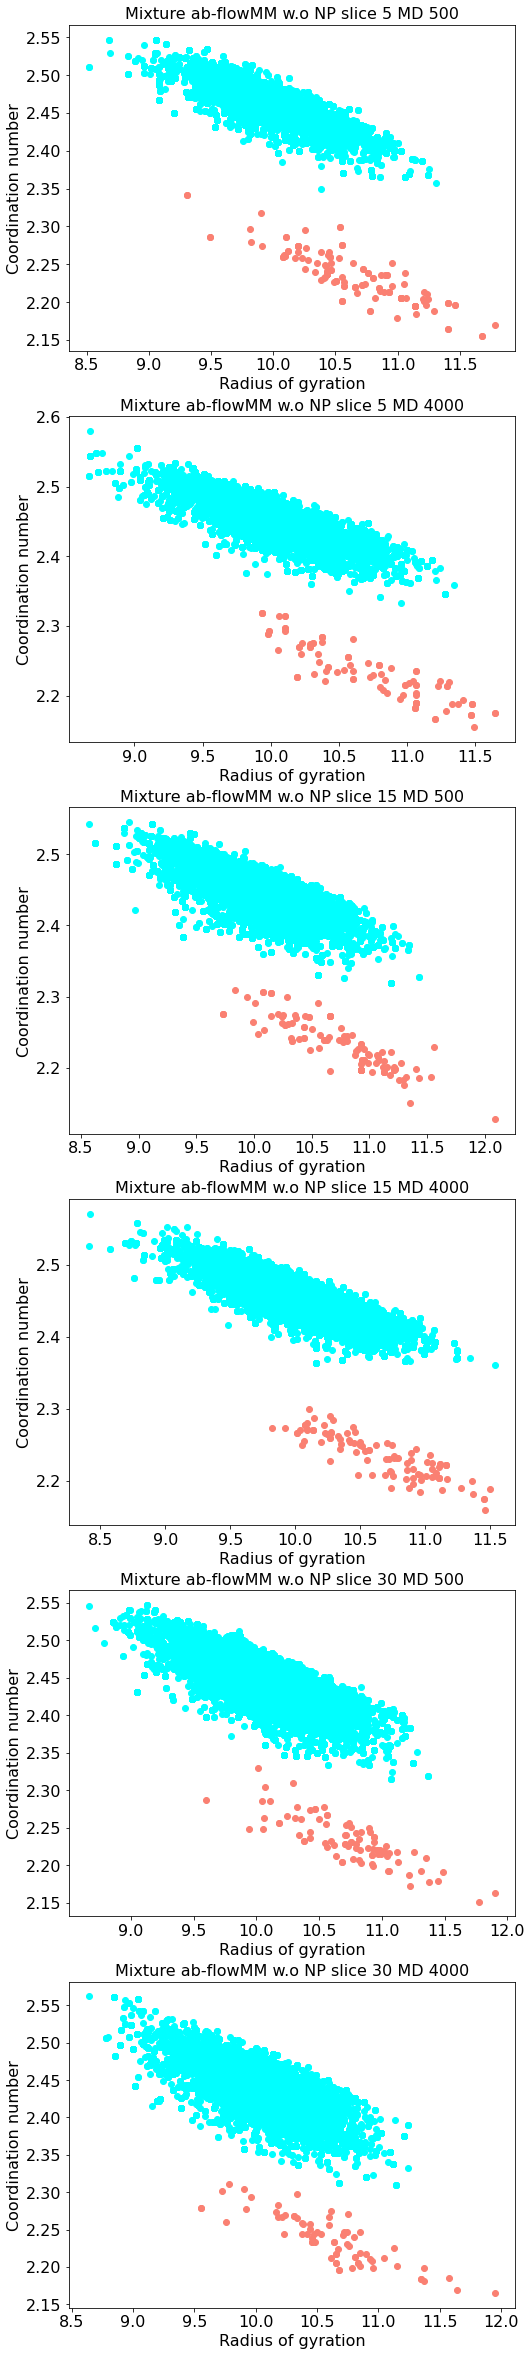

In [16]:
fig, axs = plt.subplots(len(keys), 1, figsize=(8, 7*len(keys)))

axs = axs.ravel()

for ax, key in zip(axs, cvs.keys()):
    for isomer in [0, 1]:
        mask = cvs_isomers[key][:, :, 2] == isomer

        cvs_flatten = cvs_isomers[key][mask].reshape(-1, 3)
        ax.scatter(cvs_flatten[:, 0], cvs_flatten[:, 1], 
                   label='Isomer {:d}'.format(isomer), color=isomer_colors[isomer])
    
    ax.set_title('Mixture {:s}'.format(key))
    ax.set_xlabel('Radius of gyration')
    ax.set_ylabel('Coordination number')

    #ax.set_xlim(8.5, 12)
    #ax.set_ylim(2.0, 2.6)

# Jumps along chains

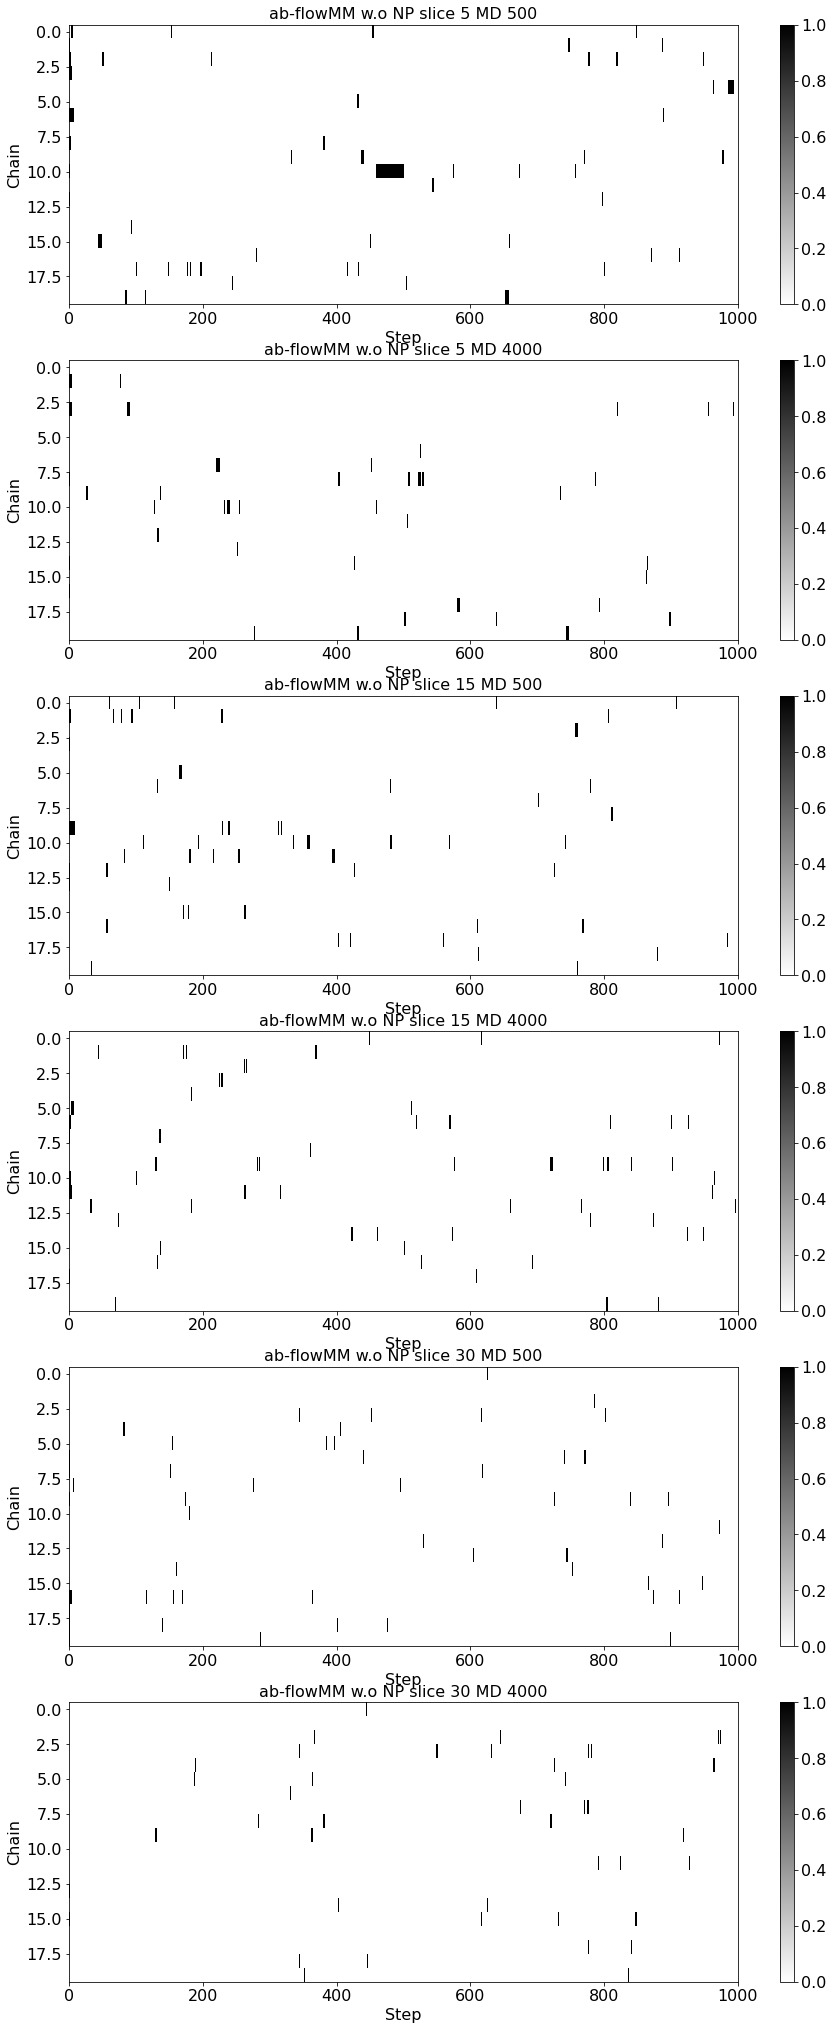

In [17]:
fig, axs = plt.subplots(len(keys), 1, figsize=(15, 6*len(keys)))
for key, ax in zip(keys, axs):
    ax.imshow(isomers[key].numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
    ax.set_xlabel('Step')
    ax.set_ylabel('Chain')
    ax.set_title(key)
    fig.colorbar(ax.imshow(isomers[key].numpy().T, aspect='auto', cmap='gray_r', interpolation='none'), ax=ax)

# Rhat

In [18]:
rhat = {key: R_hat(torch.cat((cvs[key], mcmcs[key]['us'].reshape(1001, 20, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=['Coordination number', 'Radius of gyration', 'Energy']) for key in keys if key != 'MD'}

In [19]:
color_keys[keys[0]]

'blue'

In [20]:
import matplotlib.patches as mpatches

patches = [mpatches.Patch(color=color_keys[keys[i]], label=keys[i]) for i in range(len(keys))]

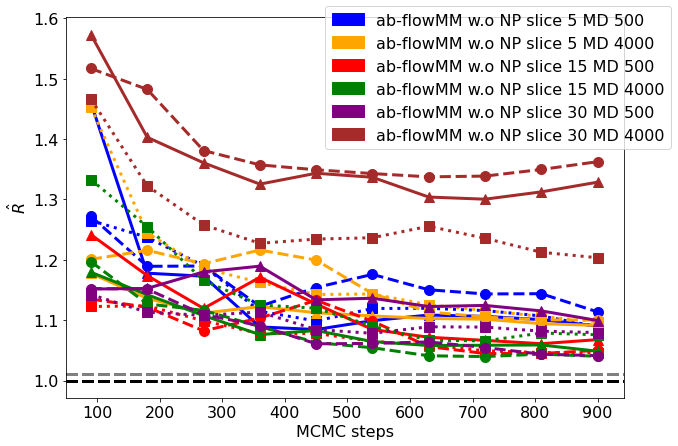

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

markers = ['o', 's', '^']
linestyles = ['dashed', 'dotted', '-']
for key in rhat.keys():
    for i in range(rhat[key][0].shape[-1]):
        axs.plot(rhat[key][1], 
                rhat[key][0][:, i], 
                linestyle=linestyles[i], 
                marker=markers[i],
                markersize=10,
                linewidth=3,
                color=color_keys[key], 
                )

        axs.axhline(1, c='k', ls='--', linewidth=3)
        axs.axhline(1.01, c='grey', ls='--', linewidth=3)

        axs.set_xlabel('MCMC steps')
        axs.set_ylabel(r'$\hat{R}$')

        axs.legend(bbox_to_anchor=(1.1, 1.05), handles=patches)

# Energies

Text(0.5, 1.0, 'Energy histogram')

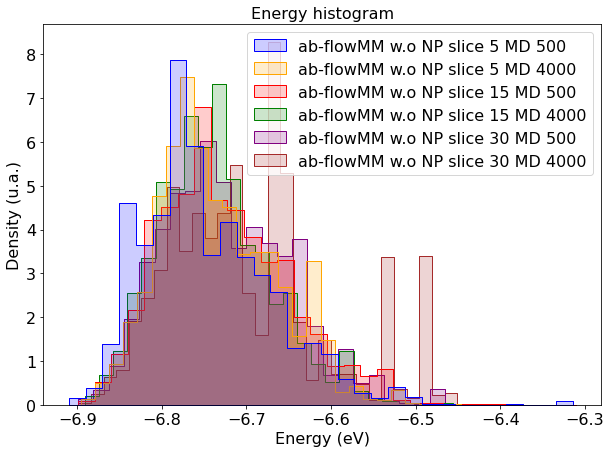

In [22]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, 
                      ax=axs, 
                      bins=30, 
                      alpha=0.2, 
                      element='step', 
                      common_bins=False, 
                      common_norm=False,
                      palette=color_keys,)
axs.set_title(f'Energy histogram')

# Populations

(0.0, 0.02)

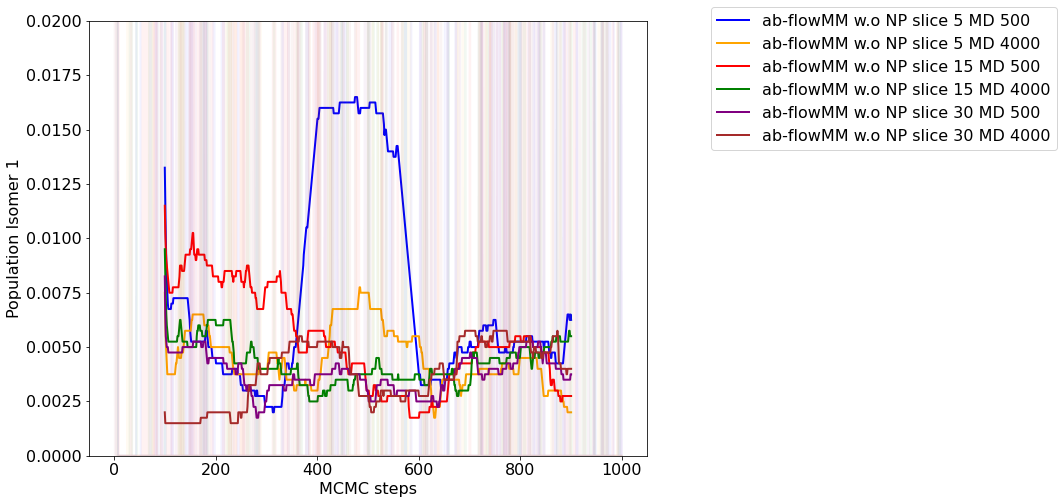

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
n=0
for key in keys:
    set_plot_sequential_data(isomers[key][n:, :].mean(dim=1).detach(), 
        avg=True, 
        window_size=200, 
        ax=ax,
        linewidth=2,
        label=key, color=color_keys[key], alpha=0.05)

    #ax.axhline(isomers[key][n:, :].mean().detach(), 0, 2000, 
    #            linestyle='--', color='red',
    #            label='Mean {:.1e}'.format(isomers[key][n:, :].mean().detach()) )

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population Isomer 1')
#ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.1, 1.05))

ax.set_ylim(0, 0.02)